**BAR CHARTS**:

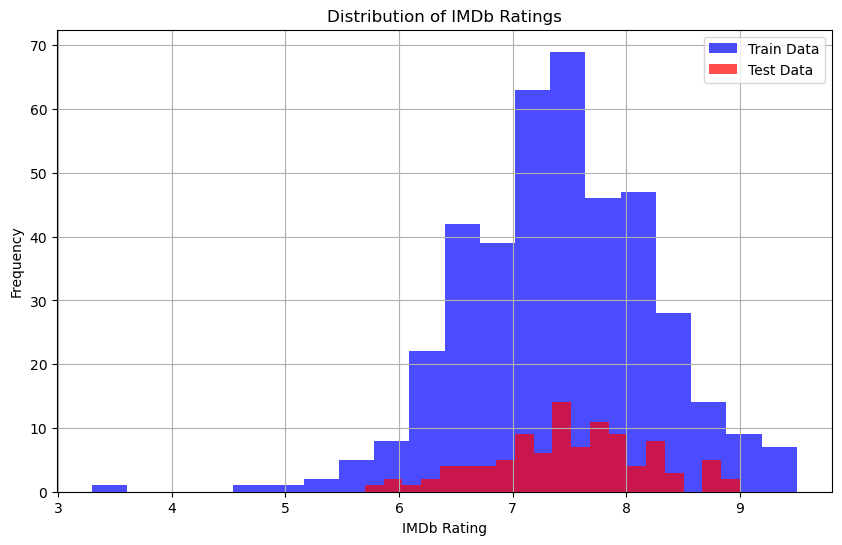

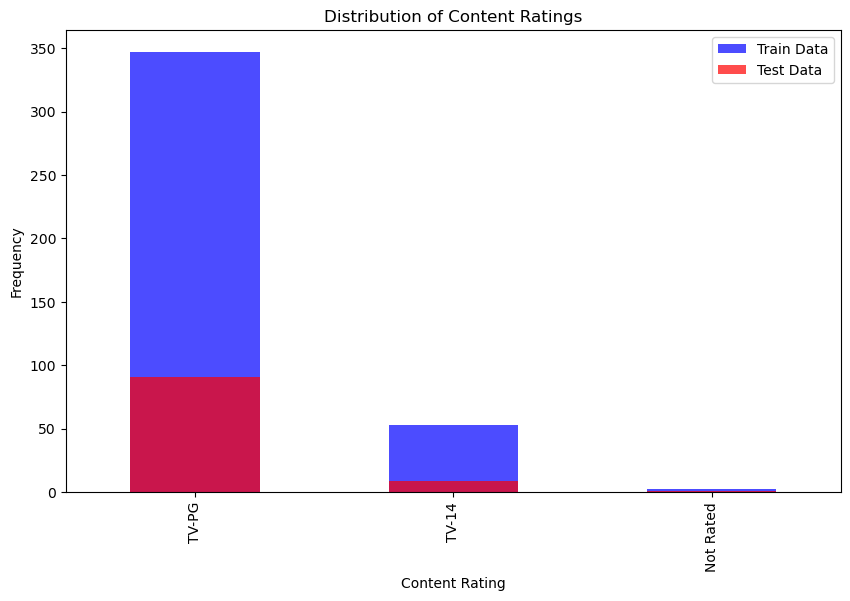

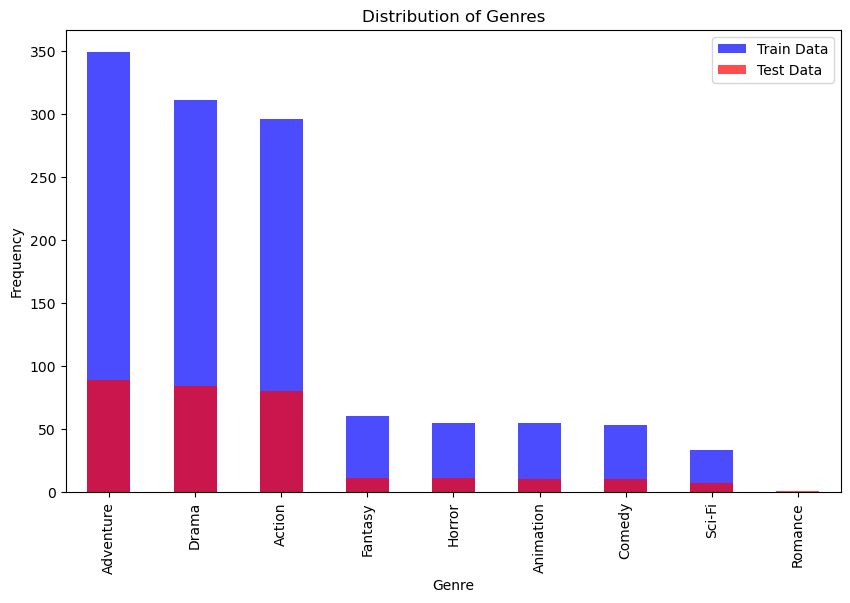

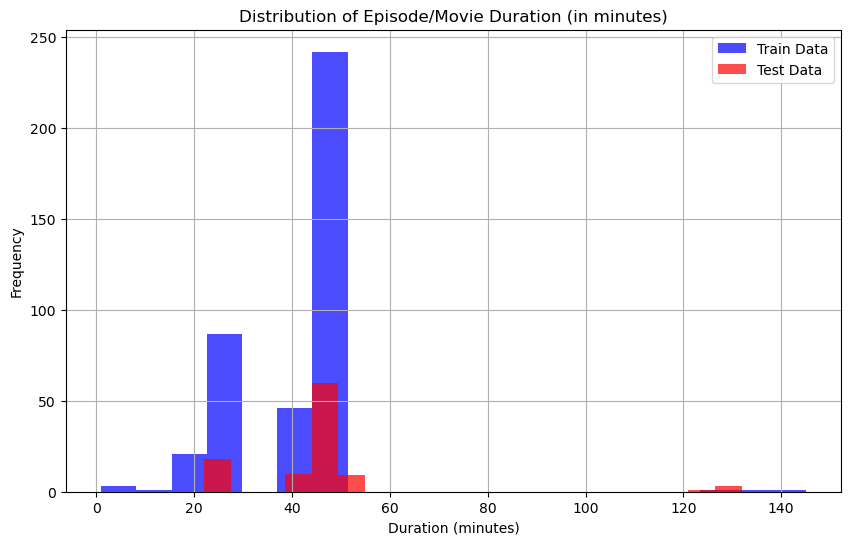

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

imdb_train = pd.read_csv('IMDb_train.csv')
imdb_test = pd.read_csv('IMDb_test.csv')

def convert_duration(duration):
    if pd.isnull(duration):
        return None
    return int(duration.replace('PT', '').replace('H', '').replace('M', '').replace('T', ''))

# Preprocess durations
imdb_train['duration_minutes'] = imdb_train['duration'].apply(convert_duration)
imdb_test['duration_minutes'] = imdb_test['duration'].apply(convert_duration)

# IMDb Ratings Distribution
plt.figure(figsize=(10, 6))
imdb_train['IMDb rating'].hist(bins=20, alpha=0.7, color='blue', label='Train Data')
imdb_test['IMDb rating'].hist(bins=20, alpha=0.7, color='red', label='Test Data')
plt.title('Distribution of IMDb Ratings')
plt.xlabel('IMDb Rating')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Content Ratings Distribution
plt.figure(figsize=(10, 6))
imdb_train['content rating'].value_counts().plot(kind='bar', alpha=0.7, color='blue', label='Train Data')
imdb_test['content rating'].value_counts().plot(kind='bar', alpha=0.7, color='red', label='Test Data')
plt.title('Distribution of Content Ratings')
plt.xlabel('Content Rating')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Genres Distribution
train_genres = imdb_train['genre'].apply(eval).explode()
test_genres = imdb_test['genre'].apply(eval).explode()
plt.figure(figsize=(10, 6))
train_genres.value_counts().plot(kind='bar', alpha=0.7, color='blue', label='Train Data')
test_genres.value_counts().plot(kind='bar', alpha=0.7, color='red', label='Test Data')
plt.title('Distribution of Genres')
plt.xlabel('Genre')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Episode/Movie Duration Distribution
plt.figure(figsize=(10, 6))
imdb_train['duration_minutes'].hist(bins=20, alpha=0.7, color='blue', label='Train Data')
imdb_test['duration_minutes'].hist(bins=20, alpha=0.7, color='red', label='Test Data')
plt.title('Distribution of Episode/Movie Duration (in minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**CO-OCCURENCE**:


/var/folders/pc/3179syv50sb1_zjwkk1yydk00000gn/T/ipykernel_36300/2070633220.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cooccurrence_matrix = pd.DataFrame(index=unique_genres, columns=unique_genres).fillna(0)


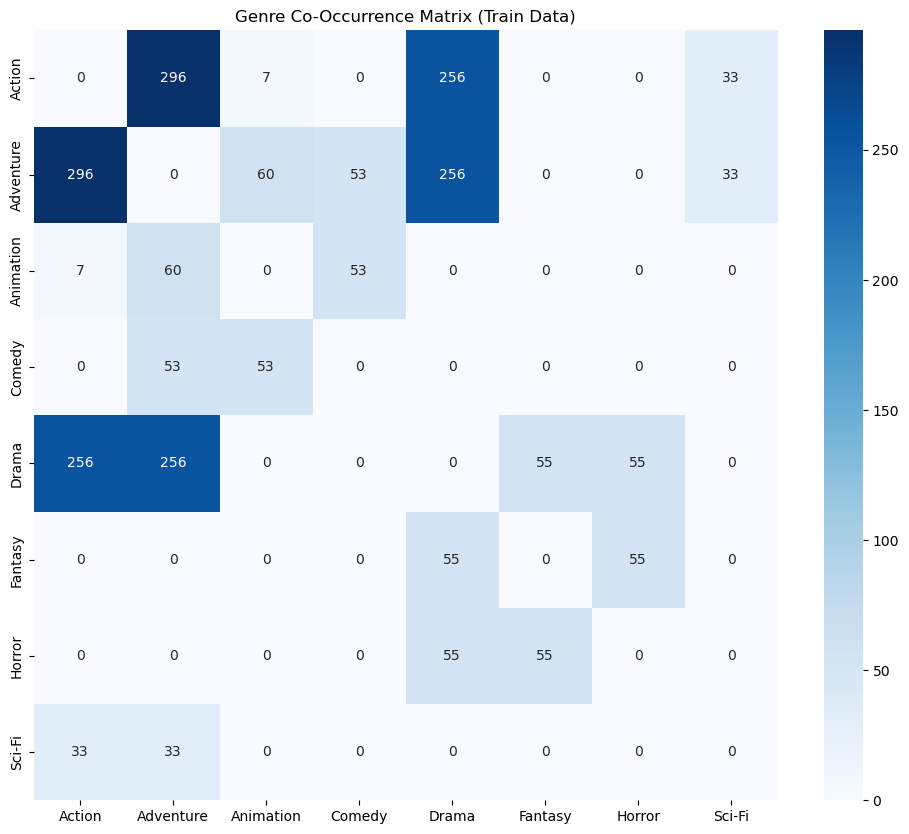

/var/folders/pc/3179syv50sb1_zjwkk1yydk00000gn/T/ipykernel_36300/2070633220.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cooccurrence_matrix = pd.DataFrame(index=unique_genres, columns=unique_genres).fillna(0)


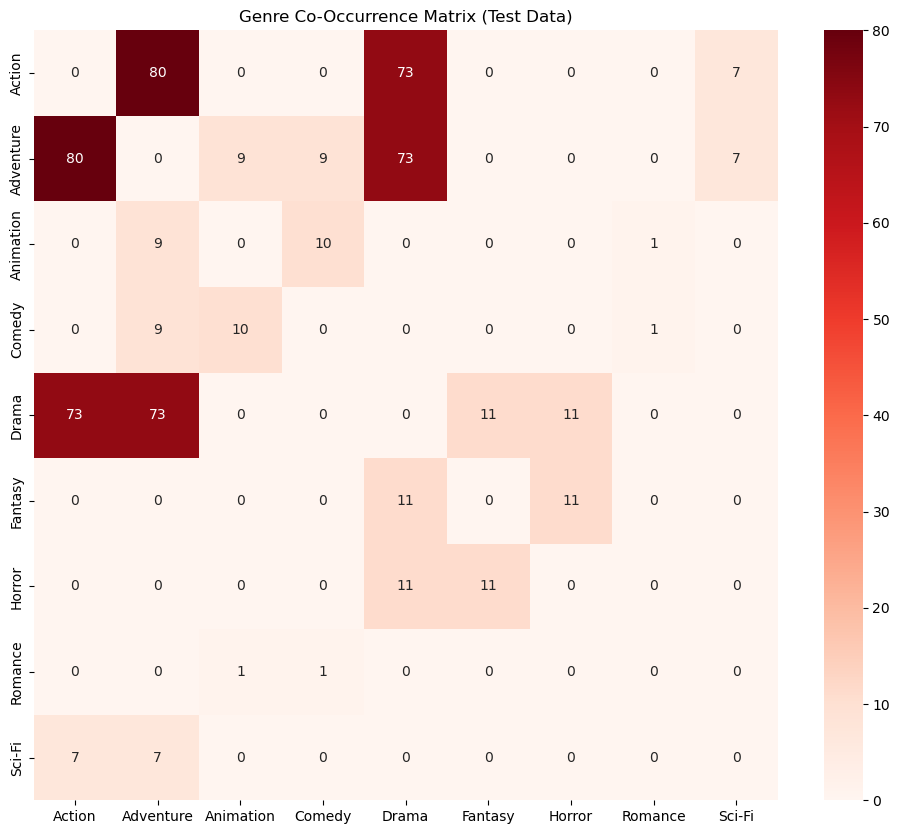

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

imdb_train = pd.read_csv('IMDb_train.csv')
imdb_test = pd.read_csv('IMDb_test.csv')


def calculate_cooccurrence(data, column):
    # Convert string representation of lists to actual lists
    data[column] = data[column].apply(eval)
    
    # Count genre pairs
    genre_pairs = []
    for genres in data[column]:
        genre_pairs += list(combinations(sorted(genres), 2))
    
    pair_counts = Counter(genre_pairs)
    
    # Create a DataFrame for the co-occurrence matrix
    unique_genres = sorted(set([item for sublist in data[column] for item in sublist]))
    cooccurrence_matrix = pd.DataFrame(index=unique_genres, columns=unique_genres).fillna(0)
    
    for (genre1, genre2), count in pair_counts.items():
        cooccurrence_matrix.loc[genre1, genre2] = count
        cooccurrence_matrix.loc[genre2, genre1] = count  # Symmetric matrix
    
    return cooccurrence_matrix

# Calculate co-occurrence for training data
train_cooccurrence_matrix = calculate_cooccurrence(imdb_train, 'genre')

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(train_cooccurrence_matrix, annot=True, fmt="g", cmap="Blues", cbar=True)
plt.title("Genre Co-Occurrence Matrix (Train Data)")
plt.show()

# Calculate co-occurrence for test data
test_cooccurrence_matrix = calculate_cooccurrence(imdb_test, 'genre')

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(test_cooccurrence_matrix, annot=True, fmt="g", cmap="Reds", cbar=True)
plt.title("Genre Co-Occurrence Matrix (Test Data)")
plt.show()

Cooccurence Themes: 

/var/folders/pc/3179syv50sb1_zjwkk1yydk00000gn/T/ipykernel_36300/1405971241.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cooccurrence_matrix = pd.DataFrame(index=unique_themes, columns=unique_themes).fillna(0)


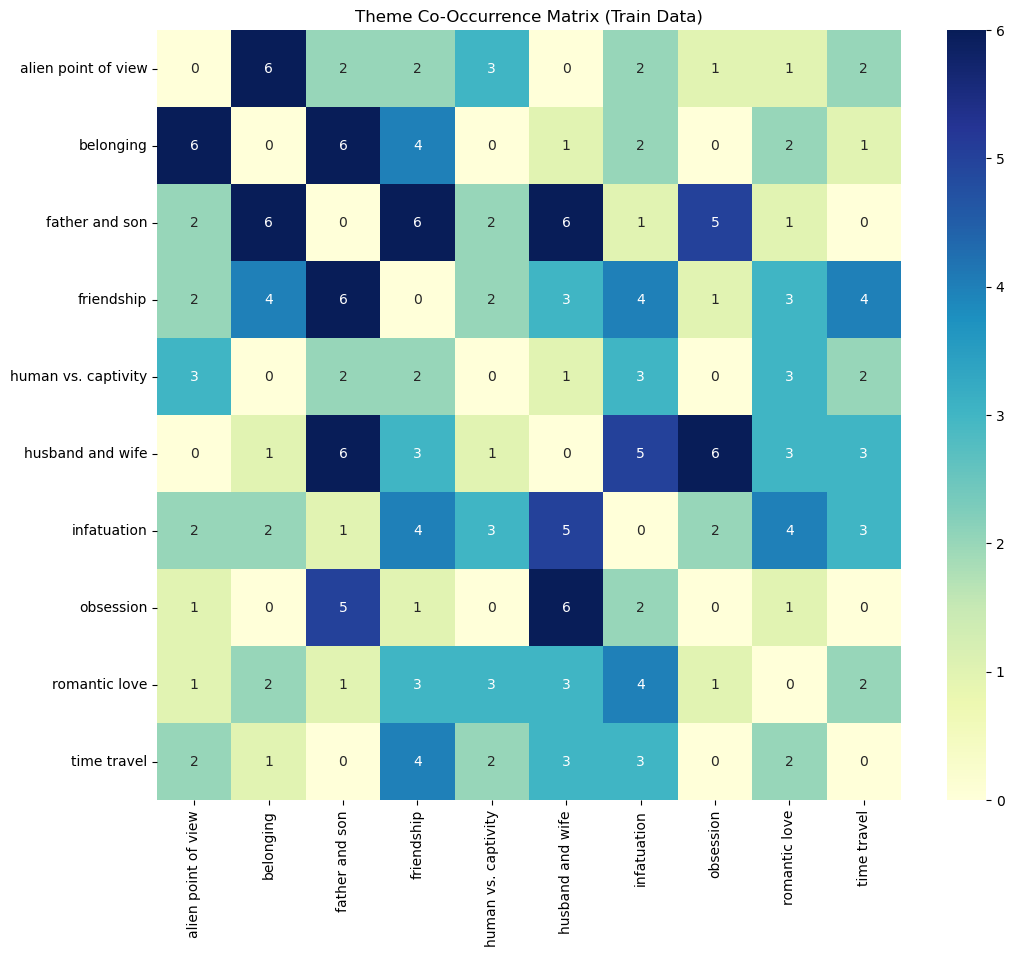

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

y_train = pd.read_csv('y_train.csv')

def calculate_theme_cooccurrence(data):
    # Count theme pairs (rows represent labels)
    theme_pairs = []
    for index, row in data.iterrows():
        # Get the indices of the themes that are '1' (indicating presence)
        active_themes = row[row == 1].index.tolist()
        theme_pairs += list(combinations(sorted(active_themes), 2))  # Sort to avoid duplication
    
    pair_counts = Counter(theme_pairs)
    
    # Create a DataFrame for the co-occurrence matrix
    unique_themes = data.columns.tolist()
    cooccurrence_matrix = pd.DataFrame(index=unique_themes, columns=unique_themes).fillna(0)
    
    for (theme1, theme2), count in pair_counts.items():
        cooccurrence_matrix.loc[theme1, theme2] = count
        cooccurrence_matrix.loc[theme2, theme1] = count  # Symmetric matrix
    
    return cooccurrence_matrix

# Calculate theme co-occurrence for training data
theme_cooccurrence_matrix = calculate_theme_cooccurrence(y_train)

# Plot the heatmap for theme co-occurrence
plt.figure(figsize=(12, 10))
sns.heatmap(theme_cooccurrence_matrix, annot=True, fmt="g", cmap="YlGnBu", cbar=True)
plt.title("Theme Co-Occurrence Matrix (Train Data)")
plt.show()

Class distribution

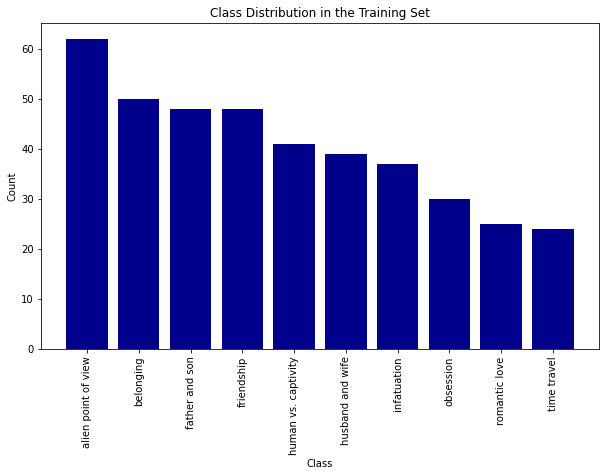

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load data
X_train = pd.read_csv('Datasets/cleaned_X_train2.csv')
y_train = pd.read_csv('Datasets/y_train.csv')
y_train = y_train.idxmax(axis=1)

# Class distribution data
class_counts = pd.Series(y_train).value_counts()

# Map the class indices back to the theme names
class_names = label_encoder.classes_

# Plot
plt.figure(figsize=(10, 6))
plt.bar(class_counts.index, class_counts.values, color='darkblue')
plt.title('Class Distribution in the Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(class_counts.index, class_names, rotation=90)  
plt.show()


Results visualization presentation

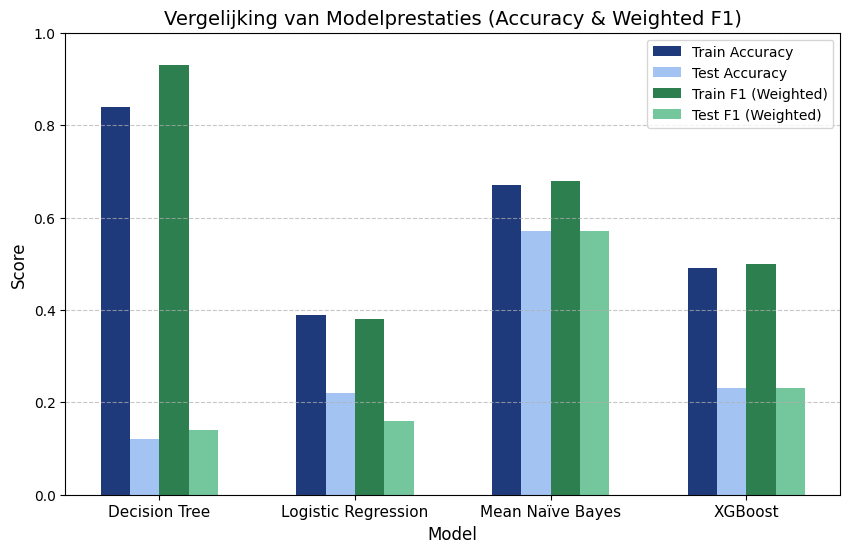

In [1]:
import numpy as np
import matplotlib.pyplot as plt

models = ["Decision Tree", "Logistic Regression", "Mean Naïve Bayes", "XGBoost"]

train_accuracy = [0.84, 0.39, 0.67, 0.49]
test_accuracy = [0.12, 0.22, 0.57, 0.23]
train_f1 = [0.93, 0.38, 0.68, 0.5]
test_f1 = [0.14, 0.16, 0.57, 0.23]

bar_width = 0.15  
x = np.arange(len(models))

plt.figure(figsize=(10, 6))

# Plot bars
plt.bar(x - 1.5 * bar_width, train_accuracy, width=bar_width, label="Train Accuracy", color="#1f3a7b")  # Dark Blue
plt.bar(x - 0.5 * bar_width, test_accuracy, width=bar_width, label="Test Accuracy", color="#a3c4f3")  # Light Blue
plt.bar(x + 0.5 * bar_width, train_f1, width=bar_width, label="Train F1 (Weighted)", color="#2d7f4f")  # Green
plt.bar(x + 1.5 * bar_width, test_f1, width=bar_width, label="Test F1 (Weighted)", color="#74c69d")  # Light Green

# Labels and title
plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Vergelijking van Modelprestaties (Accuracy & Weighted F1)", fontsize=14)
plt.xticks(ticks=x, labels=models, fontsize=11)
plt.ylim(0, 1)  


plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()
